# Implementação do algoritmo ACO para o problema do Caixeiro Viajante

Tema 2: implementação e avaliação do algoritmo ACO para o Problema do Caixeiro Viajante em grafo totalmente conexo.

## Cenário A - Versão básica para verificar funcionamento do método

Esta versão usa 5 cidades e serve como base para verificar se o ACO está funcionando corretamente. A ideia é acompanhar a média das distâncias encontradas pelas formigas em cada iteração e observar se existe tendência de redução ao longo do processo.

Configuração exigida:

- Iterações: 30
- Alfa: 1
- Beta: 1
- Taxa de evaporação do feromônio: 0.03
- Feromônio inicial em todas as arestas: 0.1
- Q: 10
- Método de escolha da rota: Torneio

### Formulação usada

Cada aresta possui feromônio `tau(i,j)` e visibilidade `eta(i,j) = 1 / distancia(i,j)`. A atratividade de uma cidade candidata é:

`atratividade(i,j) = tau(i,j)^alfa * eta(i,j)^beta`

Na seleção por torneio, algumas cidades ainda não visitadas são sorteadas como candidatas e a cidade com maior atratividade vence o torneio. Depois que todas as formigas constroem suas rotas, o feromônio evapora e cada rota deposita `Q / distancia_da_rota` nas arestas percorridas.

In [10]:
import random
from dataclasses import dataclass

import matplotlib

if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.rcParams._get = matplotlib.rcParams.get

import matplotlib.pyplot as plt
import numpy as np
plt.style.use("seaborn-v0_8-whitegrid")

### Grafo completo com 5 cidades

A matriz abaixo define os pesos das arestas. Ela é simétrica, possui diagonal zero e representa um grafo totalmente conexo, pois toda cidade tem distância definida para todas as outras.

In [11]:
cidades = ["A", "B", "C", "D", "E"]

distancias = np.array(
    [
        [0, 12, 10, 19, 8],
        [12, 0, 3, 7, 6],
        [10, 3, 0, 2, 20],
        [19, 7, 2, 0, 4],
        [8, 6, 20, 4, 0],
    ],
    dtype=float,
)

def imprimir_matriz(matriz, rotulos, casas=2):
    largura = 8
    print("".ljust(largura) + "".join(cidade.rjust(largura) for cidade in rotulos))
    for cidade, linha in zip(rotulos, matriz):
        valores = "".join(f"{valor:.{casas}f}".rjust(largura) for valor in linha)
        print(cidade.ljust(largura) + valores)


imprimir_matriz(distancias, cidades, casas=0)

               A       B       C       D       E
A              0      12      10      19       8
B             12       0       3       7       6
C             10       3       0       2      20
D             19       7       2       0       4
E              8       6      20       4       0


### Visualização do grafo com pesos nas arestas

O desenho abaixo mostra o grafo totalmente conexo usado no problema. Cada cidade é um vértice e cada número sobre uma aresta representa a distância entre duas cidades.

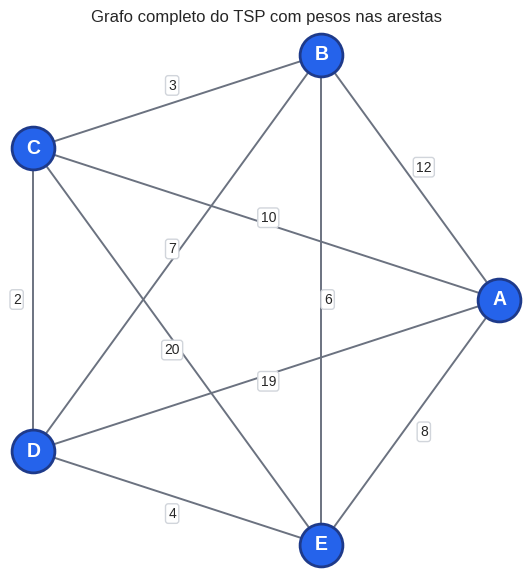

In [12]:
def visualizar_grafo_com_pesos(matriz_distancias, rotulos):
    n_cidades = len(rotulos)
    angulos = np.linspace(0, 2 * np.pi, n_cidades, endpoint=False)
    posicoes = {
        indice: np.array([np.cos(angulo), np.sin(angulo)])
        for indice, angulo in enumerate(angulos)
    }

    fig, ax = plt.subplots(figsize=(7, 7))

    for origem in range(n_cidades):
        for destino in range(origem + 1, n_cidades):
            x1, y1 = posicoes[origem]
            x2, y2 = posicoes[destino]

            ax.plot([x1, x2], [y1, y2], color="#6b7280", linewidth=1.4, zorder=1)

            meio = (posicoes[origem] + posicoes[destino]) / 2
            deslocamento = meio * 0.08
            x_texto, y_texto = meio + deslocamento

            ax.text(
                x_texto,
                y_texto,
                f"{matriz_distancias[origem, destino]:.0f}",
                ha="center",
                va="center",
                fontsize=10,
                bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "#d1d5db"},
                zorder=3,
            )

    for indice, rotulo in enumerate(rotulos):
        x, y = posicoes[indice]
        ax.scatter(x, y, s=950, color="#2563eb", edgecolor="#1e3a8a", linewidth=2, zorder=4)
        ax.text(x, y, rotulo, ha="center", va="center", color="white", fontsize=14, weight="bold", zorder=5)

    ax.set_title("Grafo completo do TSP com pesos nas arestas")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()


visualizar_grafo_com_pesos(distancias, cidades)

In [13]:
@dataclass
class ResultadoACO:
    melhor_rota: list[int]
    melhor_distancia: float
    historico_media: list[float]
    historico_melhor_iteracao: list[float]
    feromonios: np.ndarray


def distancia_rota(rota, matriz_distancias):
    total = 0.0
    for origem, destino in zip(rota, rota[1:]):
        total += matriz_distancias[origem, destino]
    total += matriz_distancias[rota[-1], rota[0]]
    return total


def escolher_proxima_cidade_torneio(
    cidade_atual,
    nao_visitadas,
    feromonios,
    matriz_distancias,
    alfa,
    beta,
    tamanho_torneio=3,
):
    quantidade = min(tamanho_torneio, len(nao_visitadas))
    candidatas = random.sample(list(nao_visitadas), quantidade)

    def atratividade(cidade):
        tau = feromonios[cidade_atual, cidade] ** alfa
        eta = (1.0 / matriz_distancias[cidade_atual, cidade]) ** beta
        return tau * eta

    return max(candidatas, key=atratividade)


def construir_rota(
    cidade_inicial,
    feromonios,
    matriz_distancias,
    alfa,
    beta,
    tamanho_torneio=3,
):
    n_cidades = len(matriz_distancias)
    rota = [cidade_inicial]
    nao_visitadas = set(range(n_cidades)) - {cidade_inicial}

    while nao_visitadas:
        proxima = escolher_proxima_cidade_torneio(
            rota[-1],
            nao_visitadas,
            feromonios,
            matriz_distancias,
            alfa,
            beta,
            tamanho_torneio,
        )
        rota.append(proxima)
        nao_visitadas.remove(proxima)

    return rota


def atualizar_feromonios(feromonios, rotas, distancias_rotas, evaporacao, q):
    feromonios *= 1.0 - evaporacao

    for rota, distancia in zip(rotas, distancias_rotas):
        deposito = q / distancia
        rota_fechada = rota + [rota[0]]

        for origem, destino in zip(rota_fechada, rota_fechada[1:]):
            feromonios[origem, destino] += deposito
            feromonios[destino, origem] += deposito

    np.fill_diagonal(feromonios, 0.0)
    return feromonios


def executar_aco(
    matriz_distancias,
    iteracoes=30,
    alfa=1,
    beta=1,
    evaporacao=0.03,
    feromonio_inicial=0.1,
    q=10,
    tamanho_torneio=3,
    semente=None,
):
    if semente is not None:
        random.seed(semente)
        np.random.seed(semente)
    else:
        random.seed()
        np.random.seed(None)

    n_cidades = len(matriz_distancias)
    feromonios = np.full((n_cidades, n_cidades), feromonio_inicial, dtype=float)
    np.fill_diagonal(feromonios, 0.0)

    melhor_rota = None
    melhor_distancia = float("inf")
    historico_media = []
    historico_melhor_iteracao = []

    for _ in range(iteracoes):
        rotas = []
        distancias_rotas = []

        # Uma formiga começa em cada cidade no ACO
        for cidade_inicial in range(n_cidades):
            rota = construir_rota(
                cidade_inicial,
                feromonios,
                matriz_distancias,
                alfa,
                beta,
                tamanho_torneio,
            )
            distancia = distancia_rota(rota, matriz_distancias)
            rotas.append(rota)
            distancias_rotas.append(distancia)

            if distancia < melhor_distancia:
                melhor_distancia = distancia
                melhor_rota = rota.copy()

        historico_media.append(float(np.mean(distancias_rotas)))
        historico_melhor_iteracao.append(float(np.min(distancias_rotas)))
        feromonios = atualizar_feromonios(
            feromonios,
            rotas,
            distancias_rotas,
            evaporacao,
            q,
        )

    return ResultadoACO(
        melhor_rota=melhor_rota,
        melhor_distancia=melhor_distancia,
        historico_media=historico_media,
        historico_melhor_iteracao=historico_melhor_iteracao,
        feromonios=feromonios,
    )

### Execução da versão básica

In [14]:
resultado = executar_aco(
    distancias,
    iteracoes=30,
    alfa=1,
    beta=1,
    evaporacao=0.03,
    feromonio_inicial=0.1,
    q=10,
    tamanho_torneio=3,
)

melhor_rota_nomes = [cidades[i] for i in resultado.melhor_rota] + [cidades[resultado.melhor_rota[0]]]

print("Melhor rota encontrada:", " -> ".join(melhor_rota_nomes))
print(f"Distância da melhor rota: {resultado.melhor_distancia:.2f}")

Melhor rota encontrada: A -> E -> D -> C -> B -> A
Distância da melhor rota: 29.00


In [15]:
historico = []

for iteracao, media, melhor in zip(
    range(1, 31),
    resultado.historico_media,
    resultado.historico_melhor_iteracao,
):
    historico.append(
        {
            "Iteração": iteracao,
            "Média das soluções": media,
            "Melhor solução da iteração": melhor,
        }
    )

print(f"{'Iteração':>8} | {'Média das soluções':>19} | {'Melhor da iteração':>19}")
print("-" * 56)
for linha in historico:
    print(
        f"{linha['Iteração']:>8} | "
        f"{linha['Média das soluções']:>19.2f} | "
        f"{linha['Melhor solução da iteração']:>19.2f}"
    )

Iteração |  Média das soluções |  Melhor da iteração
--------------------------------------------------------
       1 |               33.40 |               29.00
       2 |               33.40 |               29.00
       3 |               30.80 |               29.00
       4 |               29.00 |               29.00
       5 |               29.00 |               29.00
       6 |               29.00 |               29.00
       7 |               29.00 |               29.00
       8 |               29.00 |               29.00
       9 |               29.00 |               29.00
      10 |               29.00 |               29.00
      11 |               29.00 |               29.00
      12 |               29.00 |               29.00
      13 |               29.00 |               29.00
      14 |               29.00 |               29.00
      15 |               29.00 |               29.00
      16 |               29.00 |               29.00
      17 |               29.00 |          

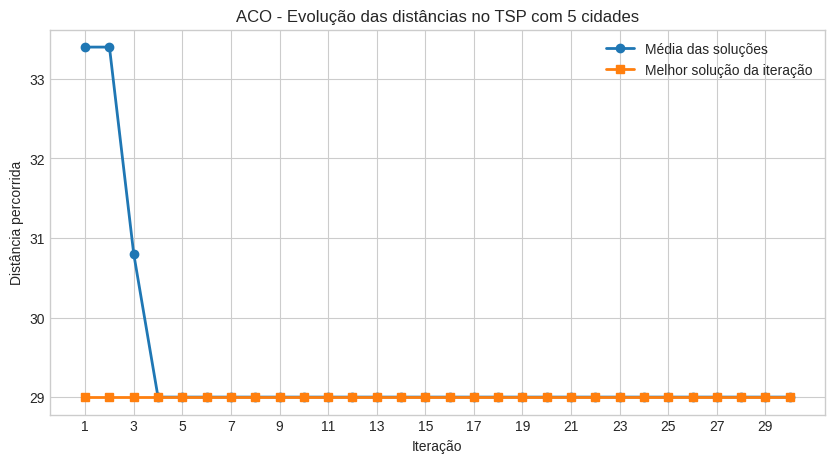

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    [linha["Iteração"] for linha in historico],
    [linha["Média das soluções"] for linha in historico],
    marker="o",
    linewidth=2,
    label="Média das soluções",
)
ax.plot(
    [linha["Iteração"] for linha in historico],
    [linha["Melhor solução da iteração"] for linha in historico],
    marker="s",
    linewidth=2,
    label="Melhor solução da iteração",
)

ax.set_title("ACO - Evolução das distâncias no TSP com 5 cidades")
ax.set_xlabel("Iteração")
ax.set_ylabel("Distância percorrida")
ax.set_xticks(range(1, 31, 2))
ax.legend()

plt.show()

### Comentário sobre o funcionamento

O gráfico mostra a evolução da média das soluções geradas pelas formigas a cada iteração. Como o método usa torneio com sorteio de candidatas, a média pode oscilar de uma iteração para outra. Mesmo assim, o comportamento esperado é que as soluções ruins percam força pela evaporação e as melhores rotas recebam mais feromônio, fazendo a busca se concentrar gradualmente em caminhos menores.

Nesta configuração, a melhor rota encontrada e a queda ou estabilização das médias indicam se o método está funcionando corretamente para servir de base aos próximos testes de parâmetros.

### Matriz da melhor rota encontrada

A matriz abaixo mostra somente as arestas que fazem parte da melhor rota encontrada pelo ACO. Os valores exibidos são as distâncias reais entre as cidades; as posições com `0` indicam arestas que não fazem parte da rota final.


In [17]:
def matriz_melhor_rota(rota, matriz_distancias):
    matriz_rota = np.zeros_like(matriz_distancias)
    rota_fechada = rota + [rota[0]]

    for origem, destino in zip(rota_fechada, rota_fechada[1:]):
        matriz_rota[origem, destino] = matriz_distancias[origem, destino]
        matriz_rota[destino, origem] = matriz_distancias[origem, destino]

    return matriz_rota


matriz_rota_final = matriz_melhor_rota(resultado.melhor_rota, distancias)
imprimir_matriz(matriz_rota_final, cidades, casas=0)


               A       B       C       D       E
A              0      12       0       0       8
B             12       0       3       0       0
C              0       3       0       2       0
D              0       0       2       0       4
E              8       0       0       4       0


### Visualização da melhor rota encontrada

A figura abaixo mostra somente a melhor rota encontrada pelo ACO. Os números nas arestas representam as distâncias entre as cidades.


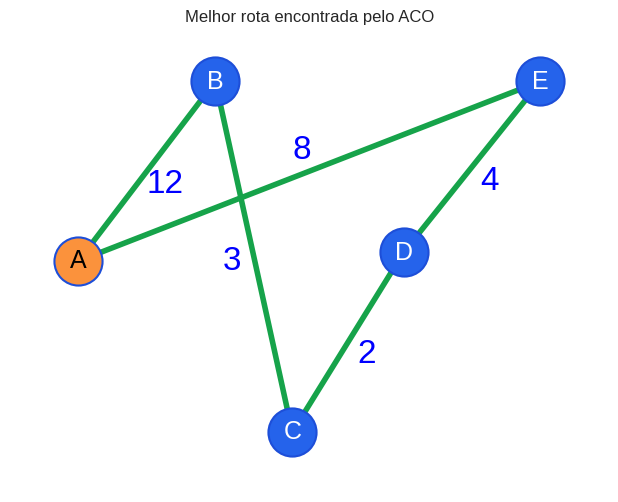

In [18]:
def visualizar_melhor_rota(rota, matriz_distancias, rotulos):
    posicoes = {
        0: np.array([-1.35, 0.00]),  # A
        1: np.array([-0.55, 1.05]),  # B
        2: np.array([-0.10, -1.00]), # C
        3: np.array([0.55, 0.05]),   # D
        4: np.array([1.35, 1.05]),   # E
    }

    rota_fechada = rota + [rota[0]]
    fig, ax = plt.subplots(figsize=(9, 6))

    for origem, destino in zip(rota_fechada, rota_fechada[1:]):
        p1 = posicoes[origem]
        p2 = posicoes[destino]
        meio = (p1 + p2) / 2
        vetor = p2 - p1
        tamanho = np.linalg.norm(vetor)
        normal = np.array([-vetor[1], vetor[0]]) / tamanho

        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="#16a34a", linewidth=4, zorder=1)

        pos_texto = meio + normal * 0.13
        ax.text(
            pos_texto[0],
            pos_texto[1],
            f"{matriz_distancias[origem, destino]:.0f}",
            color="blue",
            fontsize=24,
            ha="center",
            va="center",
            zorder=3,
        )

    cidade_inicial = rota[0]
    for indice, rotulo in enumerate(rotulos):
        x, y = posicoes[indice]
        cor = "#fb923c" if indice == cidade_inicial else "#2563eb"
        texto = "black" if indice == cidade_inicial else "white"
        ax.scatter(x, y, s=1200, color=cor, edgecolor="#1d4ed8", linewidth=1.5, zorder=4)
        ax.text(x, y, rotulo, ha="center", va="center", color=texto, fontsize=18, zorder=5)

    ax.set_title("Melhor rota encontrada pelo ACO")
    ax.set_xlim(-1.75, 1.75)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()


visualizar_melhor_rota(resultado.melhor_rota, distancias, cidades)
